In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/Users/samantha/QuantUS/engines/ceus/TwoD_CEUS_test
/Users/samantha/QuantUS/engines/ceus


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [40]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['avi', 'nifti', 'mp4']


In [41]:
scan_type = 'nifti'

scan_path = '/Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p16/wk12/combined_nifti/p16_wk12_CHI_RAW.nii'
scan_loader_kwargs = {
    'transpose': False  # Set back to False - Canon converter already rotated
    # preserve_raw will auto-detect from "_RAW" in filename
}

In [42]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [43]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['nifti', 'load_bolus_mask']


In [44]:
seg_type = 'nifti'

# ROI mask drawn on normalized data (but will be applied to raw data)
# This assumes you have a motion-corrected ROI from the Canon data
# Replace this path with your actual ROI mask file
seg_path = '/Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p16/wk12/p16_wk12_static_roi_139_displacement_mc.nii.gz'
seg_loader_kwargs = {}

In [45]:
from src.entrypoints import seg_loading_step
import numpy as np

seg_data = seg_loading_step(seg_type, image_data, seg_path, scan_path, **seg_loader_kwargs)
print(seg_data.seg_mask.shape)

(604, 524, 873)


In [46]:
# Load Optional Boundary Mask for Tighter T0 Map Visualization
import nibabel as nib

USE_BOUNDARY_MASK = False
boundary_mask_path = '/Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p16/wk12/p16_wk12_static_roi_139.nii.gz'

if USE_BOUNDARY_MASK:
    try:
        boundary_nii = nib.load(boundary_mask_path)
        boundary_mask_raw = boundary_nii.get_fdata()
        
        # Process similar to ROI mask
        if boundary_mask_raw.shape[0] == 1048:
            mid = 524
            left_half = boundary_mask_raw[:mid, :, :]
            right_half = boundary_mask_raw[mid:, :, :]
            
            if np.sum(left_half > 0) > np.sum(right_half > 0):
                boundary_mask_raw = left_half
            else:
                boundary_mask_raw = right_half
            
            if boundary_mask_raw.shape != image_data.pixel_data.shape[:3]:
                boundary_mask_raw = boundary_mask_raw.transpose(1, 0, 2)
        
        # Extract 2D mask
        if boundary_mask_raw.ndim == 3:
            boundary_mask_2d = boundary_mask_raw[:, :, 250] > 0
        else:
            boundary_mask_2d = boundary_mask_raw > 0
        
        print(f'Boundary mask loaded: {np.sum(boundary_mask_2d)} pixels')
        
    except Exception as e:
        print(f'Boundary mask error: {e}')
        boundary_mask_2d = None
        USE_BOUNDARY_MASK = False
else:
    boundary_mask_2d = None

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from matplotlib.animation import FFMpegWriter
from pathlib import Path

# Prepare data
if image_data.pixel_data.ndim == 4:
    frames = image_data.pixel_data[:,:,:,0]
else:
    frames = image_data.pixel_data

seg_mask = seg_data.seg_mask

# Normalize for display
vmin = np.percentile(frames, 0.1)
vmax = np.percentile(frames, 99.9)
frames_for_display = np.clip(frames, vmin, vmax)
frames_for_display = ((frames_for_display - vmin) / (vmax - vmin) * 255).astype(np.uint8)

# Interactive viewer
frame_slider = widgets.IntSlider(value=250, min=0, max=frames.shape[2] - 1, description='Frame', continuous_update=False)
overlay_toggle = widgets.ToggleButton(value=True, description='Show ROI')
output = widgets.Output()

def _select_seg_frame(frame_idx):
    if seg_mask.ndim == 3:
        # Always extract 2D slice from 3D mask
        # Clamp index to valid range for mask
        mask_frame_idx = min(frame_idx, seg_mask.shape[2] - 1)
        return seg_mask[:,:,mask_frame_idx]
    return seg_mask

def _render_frame(change=None):
    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(frames_for_display[:, :, frame_slider.value], cmap='gray')
        if overlay_toggle.value:
            roi_mask = _select_seg_frame(frame_slider.value)
            if np.any(roi_mask > 0):
                ax.imshow(roi_mask, alpha=0.5, cmap='Reds')
        ax.axis('off')
        plt.show()

# Export
def export_video(b):
    status_label.value = 'Exporting...'
    output_path = Path(scan_path).parent / f'{Path(scan_path).stem}_with_roi.mp4'
    
    fig, ax = plt.subplots(figsize=(8, 8))
    writer = FFMpegWriter(fps=30)
    
    with writer.saving(fig, str(output_path), dpi=100):
        for i in range(frames.shape[2]):
            if i % 50 == 0:
                status_label.value = f'{i}/{frames.shape[2]}'
            ax.clear()
            ax.imshow(frames_for_display[:, :, i], cmap='gray')
            roi_mask = _select_seg_frame(i)
            if np.any(roi_mask > 0):
                ax.imshow(roi_mask, alpha=0.5, cmap='Reds')
            ax.axis('off')
            writer.grab_frame()
    plt.close(fig)
    status_label.value = f'✓ {output_path.name}'

export_button = widgets.Button(description='Export')
status_label = widgets.Label()
export_button.on_click(export_video)

frame_slider.observe(_render_frame, names='value')
overlay_toggle.observe(_render_frame, names='value')

display(widgets.HBox([frame_slider, overlay_toggle, export_button]), status_label, output)
_render_frame()

Label(value='')

Output()

# Generating T0 map using Segmentation Mask and Pixel data.

Raw data diagnostics:
  Data type: float64
  Overall range: [0.0000, 0.6078]
  Sample ROI (frame 150) range: [0.0000, 0.0084]
  Sample ROI (frame 150) mean: 0.0007
  Sample ROI (frame 150) median: 0.0002

Otsu threshold statistics across frames 0-380:
  Mean: 0.0013
  Median: 0.0012
  Std: 0.0006
  Min: 0.0000
  Max: 0.0033

Using median threshold: 0.0012


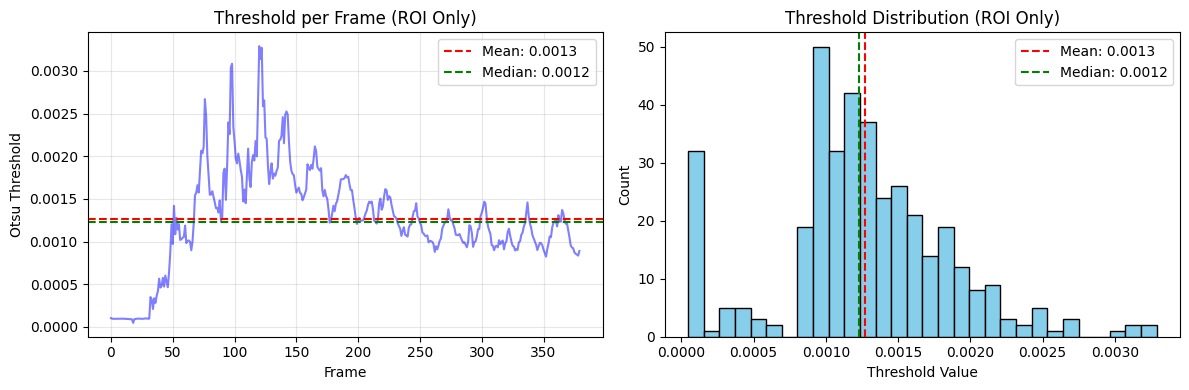

In [48]:
def otsu_threshold(frame_array, bins=256):
    values = frame_array[np.isfinite(frame_array)].astype(np.float32).ravel()
    if values.size == 0:
        raise ValueError("No valid pixels available for Otsu thresholding")
    hist, bin_edges = np.histogram(values, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    total = values.size
    sum_total = np.dot(hist, bin_centers)
    weight_background = 0.0
    sum_background = 0.0
    max_variance = 0.0
    threshold_value = float(bin_centers[0])
    for h, center in zip(hist, bin_centers):
        weight_background += h
        if weight_background == 0:
            continue
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break
        sum_background += h * center
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        between_variance = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
        if between_variance > max_variance:
            max_variance = between_variance
            threshold_value = center
    return threshold_value

# Compute Otsu across multiple frames, using ROI only
start_frame = 0
end_frame = 380

# Handle both 3D (NIfTI) and 4D (mp4) data
if image_data.pixel_data.ndim == 4:
    frames = image_data.pixel_data[:,:,:,0]
else:
    frames = image_data.pixel_data

seg_mask = seg_data.seg_mask

# First, let's check the raw data range in the ROI
print("Raw data diagnostics:")
print(f"  Data type: {frames.dtype}")
print(f"  Overall range: [{frames.min():.4f}, {frames.max():.4f}]")

# Check a sample ROI frame
sample_frame = frames[:, :, 200]
if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
    sample_roi_mask = seg_mask[:, :, 150]
else:
    sample_roi_mask = seg_mask
sample_roi_pixels = sample_frame[sample_roi_mask > 0]
print(f"  Sample ROI (frame 150) range: [{sample_roi_pixels.min():.4f}, {sample_roi_pixels.max():.4f}]")
print(f"  Sample ROI (frame 150) mean: {sample_roi_pixels.mean():.4f}")
print(f"  Sample ROI (frame 150) median: {np.median(sample_roi_pixels):.4f}")
print()

thresholds = []
for i in range(start_frame, end_frame):
    # Extract frame - NIfTI has time on third axis
    frame = np.asarray(frames[:, :, i], dtype=np.float32)
    
    # Extract corresponding ROI mask frame (if motion-corrected)
    if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
        roi_mask = seg_mask[:, :, i]
    else:
        roi_mask = seg_mask
    
    # Extract only ROI pixels
    roi_pixels = frame[roi_mask > 0]
    
    if roi_pixels.size > 0:
        thresh = otsu_threshold(roi_pixels)
        thresholds.append(thresh)

thresholds = np.array(thresholds)

# Statistics
print(f"Otsu threshold statistics across frames {start_frame}-{end_frame}:")
print(f"  Mean: {thresholds.mean():.4f}")
print(f"  Median: {np.median(thresholds):.4f}")
print(f"  Std: {thresholds.std():.4f}")
print(f"  Min: {thresholds.min():.4f}")
print(f"  Max: {thresholds.max():.4f}")

# Use median as optimal threshold
otsu_threshold_value = np.median(thresholds)
print(f"\nUsing median threshold: {otsu_threshold_value:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(start_frame, start_frame + len(thresholds)), thresholds, 'b-', alpha=0.5)
axes[0].axhline(thresholds.mean(), color='r', linestyle='--', label=f'Mean: {thresholds.mean():.4f}')
axes[0].axhline(np.median(thresholds), color='g', linestyle='--', label=f'Median: {np.median(thresholds):.4f}')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Otsu Threshold')
axes[0].set_title('Threshold per Frame (ROI Only)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(thresholds, bins=30, color='skyblue', edgecolor='black')
axes[1].axvline(thresholds.mean(), color='r', linestyle='--', label=f'Mean: {thresholds.mean():.4f}')
axes[1].axvline(np.median(thresholds), color='g', linestyle='--', label=f'Median: {np.median(thresholds):.4f}')
axes[1].set_xlabel('Threshold Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Threshold Distribution (ROI Only)')
axes[1].legend()

plt.tight_layout()
plt.show()

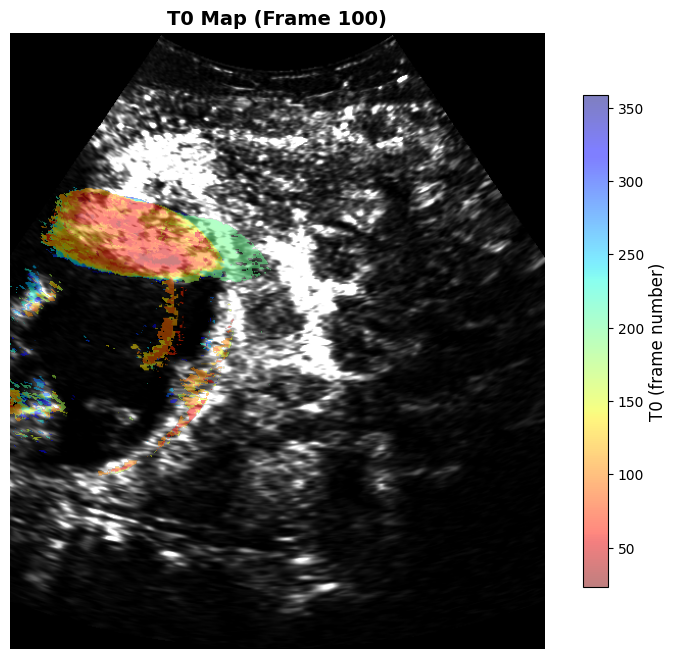

In [52]:
from TwoD_CEUS_test.T0_map import generate_t0_map, get_t0_statistics, mask_t0_map

# Prepare data
if image_data.pixel_data.ndim == 4:
    pixel_data_for_analysis = image_data.pixel_data[:,:,:,0]
else:
    pixel_data_for_analysis = image_data.pixel_data.transpose(2, 0, 1)

# Generate T0 map
threshold = 0.001
start_frame = 15
end_frame = 380
min_consecutive_frames = 6

t0_map = generate_t0_map(pixel_data_for_analysis, seg_data.seg_mask, threshold, start_frame, end_frame, min_consecutive_frames)
masked_t0_map = mask_t0_map(t0_map, seg_data.seg_mask)
masked_t0_map_transparent = masked_t0_map.copy().astype(float)
masked_t0_map_transparent[masked_t0_map == 0] = np.nan

# Apply boundary mask if enabled
apply_boundary = False
t0_map_for_viz = masked_t0_map_transparent.copy()
if apply_boundary and USE_BOUNDARY_MASK and boundary_mask_2d is not None:
    t0_map_for_viz[~boundary_mask_2d] = np.nan

# Display
display_frame = 100
single_image = image_data.pixel_data[:, :, display_frame]
if single_image.dtype == np.float64:
    p20, p95 = np.percentile(image_data.pixel_data, [20, 95])
    single_image_display = np.clip(single_image, p20, p95)
    single_image_display = ((single_image_display - p20) / (p95 - p20) * 255).astype(np.uint8)
else:
    single_image_display = single_image

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(single_image_display, cmap='gray')
im = ax.imshow(t0_map_for_viz, alpha=0.5, cmap='jet_r')
ax.set_title(f'T0 Map (Frame {display_frame})', fontsize=14, fontweight='bold')
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('T0 (frame number)', fontsize=12)
plt.show()

# Perform Skeletonization on the T0 map

T0 value range: [23, 359]
Using thresholds: lower=23, upper=102
Branch points: 95


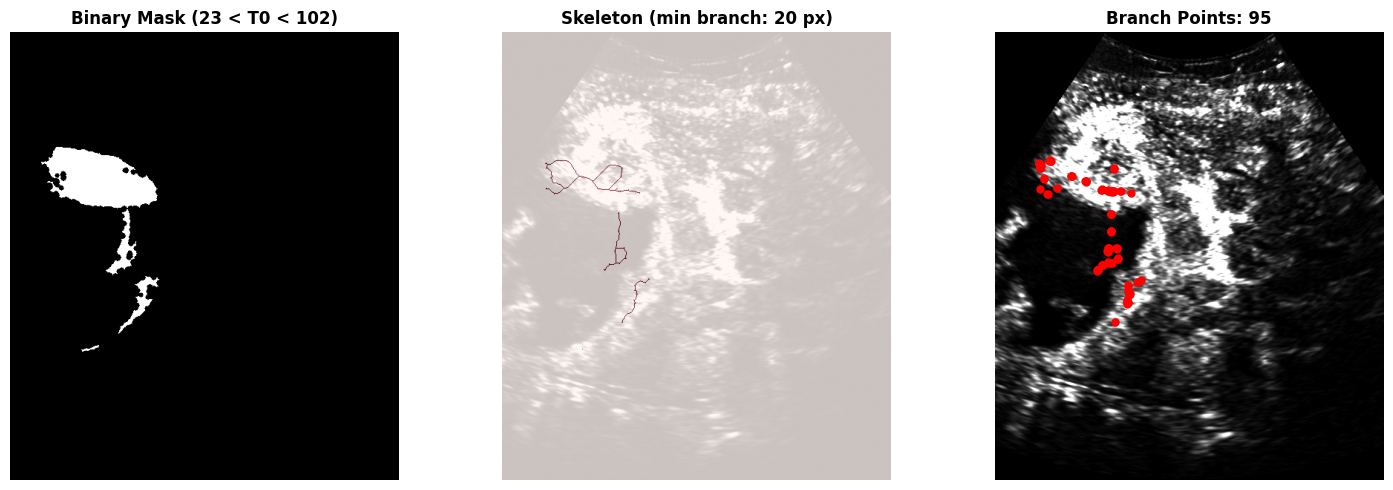

In [53]:
from skimage.morphology import skeletonize, binary_closing, disk, remove_small_objects
from scipy import ndimage

# Check T0 value range
valid_t0 = t0_map_for_viz[~np.isnan(t0_map_for_viz)]
if valid_t0.size > 0:
    print(f"T0 value range: [{valid_t0.min():.0f}, {valid_t0.max():.0f}]")

# Threshold range for binary mask (min to median of T0 values)
threshold_lower = valid_t0.min() if valid_t0.size > 0 else 0
threshold_upper = np.median(valid_t0) if valid_t0.size > 0 else None

print(f"Using thresholds: lower={threshold_lower:.0f}, upper={threshold_upper:.0f}")

# Create binary mask
if threshold_upper is not None:
    binary_mask_raw = (t0_map_for_viz > threshold_lower) & (t0_map_for_viz < threshold_upper)
else:
    binary_mask_raw = t0_map_for_viz > threshold_lower

# Apply morphological cleaning
binary_mask = binary_closing(binary_mask_raw, disk(3))
binary_mask = remove_small_objects(binary_mask, min_size=50)

# Skeletonize
skeleton = skeletonize(binary_mask)

# Prune short branches from skeleton
def prune_skeleton(skel, min_branch_length=10):
    """Remove branches shorter than min_branch_length pixels."""
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])
    pruned = skel.copy()
    for _ in range(min_branch_length):
        neighbors = ndimage.convolve(pruned.astype(int), kernel, mode='constant')
        endpoints = (neighbors == 1) & pruned
        pruned[endpoints] = False
    return pruned

# Pruning parameters
min_branch_length = 20
skeleton_pruned = prune_skeleton(skeleton, min_branch_length)

# Find branch points
kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])
neighbor_count = ndimage.convolve(skeleton_pruned.astype(int), kernel, mode='constant')
branch_points = (neighbor_count >= 3) & skeleton_pruned
num_branch_points = np.sum(branch_points)

print(f"Branch points: {num_branch_points}")

# Visualize
proj_norm = (single_image_display - single_image_display.min()) / (single_image_display.max() - single_image_display.min())
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

thresh_str = f'{threshold_lower:.0f} < T0 < {threshold_upper:.0f}' if threshold_upper else f'T0 > {threshold_lower:.0f}'

axes[0].imshow(binary_mask, cmap='gray')
axes[0].set_title(f'Binary Mask ({thresh_str})', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(proj_norm, cmap='gray')
axes[1].imshow(skeleton_pruned, cmap='Reds', alpha=0.8)
axes[1].set_title(f'Skeleton (min branch: {min_branch_length} px)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(proj_norm, cmap='gray')
axes[2].plot(np.where(branch_points)[1], np.where(branch_points)[0], 'r.', markersize=10)
axes[2].set_title(f'Branch Points: {num_branch_points}', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()